# FP architecture sweeps - results

Each section reads its checkpoints directly. Label = `BACKBONE (depth) - pooling` (`None` = depth-0 pool-only baseline). Color = pooling, marker = backbone.

Per task: leaderboard table, val-MAE barplot (embedding-NN k-sweep null models pinned at the top, outside the ranking), a val-vs-test scatter, and pred-vs-truth scatters for the top-3 configs on the validation set (MAE + R$^2$ in each corner).

In [43]:
# Shared loaders + plotters. Each sweep is read straight from its checkpoints.
import glob, os
import numpy as np, pandas as pd, torch
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC = True
except Exception:
    HAVE_APC = False
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

FS = 12
plt.rcParams.update({"font.size": FS, "axes.titlesize": FS, "axes.labelsize": FS,
                     "xtick.labelsize": FS, "ytick.labelsize": FS, "legend.fontsize": FS})

BB = {"cnn": "CNN", "transformer": "TF", "mlp": "None"}
POOL_C = {"mean": "#9a9a9a", "max": "#2b6c8f", "concat": "#f6a200", "concatstd": "#c5474b",
          "attn": "#3b8a6e", "null": "#111111"}
ARCH_M = {"mlp": "o", "cnn": "s", "transformer": "^"}
POOL_ORDER = ["mean", "max", "concat", "concatstd", "attn"]

def load_sweep(out_dir):
    recs = []
    for p in glob.glob(f"{out_dir}/*.pt"):
        ck = torch.load(p, map_location="cpu", weights_only=False)
        r = dict(arch=ck["arch"], pool=ck["pool"], depth=ck.get("depth"), seed=ck["seed"],
                 val_mae=ck["val_mae"], test_mae=ck["test_mae"],
                 label=f"{BB[ck['arch']]} ({ck.get('depth')}) - {ck['pool']}")
        if "val_ex" in ck:
            r["val_ex"] = ck["val_ex"]; r["val_em"] = ck["val_em"]
        recs.append(r)
    if not recs:
        print(f"(no checkpoints in {out_dir} yet)"); return None
    df = pd.DataFrame(recs)
    aggd = {"n_seeds": ("seed", "nunique"), "val_mae": ("val_mae", "mean"), "val_std": ("val_mae", "std"),
            "test_mae": ("test_mae", "mean"), "test_std": ("test_mae", "std")}
    if "val_ex" in df:
        aggd.update(val_ex=("val_ex", "mean"), val_em=("val_em", "mean"))
    agg = df.groupby(["label", "arch", "pool", "depth"]).agg(**aggd).reset_index()
    agg[["val_std", "test_std"]] = agg[["val_std", "test_std"]].fillna(0.0)
    return agg.sort_values("val_mae").reset_index(drop=True)

def show_table(agg):
    if agg is None: return "no checkpoints yet"
    cols = ["label", "arch", "pool", "depth", "n_seeds", "val_mae", "val_std", "test_mae", "test_std"]
    if "val_ex" in agg: cols += ["val_ex", "val_em"]
    return agg[cols].round(3)

def plot_bar(agg, unit, title, nulls=None):
    if agg is None: print("no data"); return
    cfg = agg[["label", "pool", "val_mae", "val_std"]].sort_values("val_mae", ascending=False).reset_index(drop=True)
    yc = np.arange(len(cfg))
    gap = 1.0
    n_null = len(nulls) if nulls else 0
    total = len(cfg) + (n_null + gap if n_null else 0)
    fig, ax = plt.subplots(figsize=(8.5, max(4.5, 0.2 * total)))
    ax.barh(yc, cfg["val_mae"], xerr=cfg["val_std"], capsize=2, edgecolor="black", linewidth=0.3,
            color=[POOL_C.get(p, "#333") for p in cfg["pool"]])
    yticks, ylabels = list(yc), list(cfg["label"])
    if nulls:                                                    # null models pinned ABOVE the ranking
        items = list(nulls.items())
        yn = np.arange(n_null) + len(cfg) + gap
        ax.barh(yn, [v for _, v in items], color=POOL_C["null"], edgecolor="black", linewidth=0.3)
        ax.axhline(len(cfg) - 0.5 + gap / 2, ls=":", color="0.5", lw=1)
        yticks += list(yn); ylabels += [k for k, _ in items]
    ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=FS)
    ax.set_xlabel(f"validation MAE ({unit})"); ax.set_title(title)
    handles = [Patch(color=POOL_C[p], label=p) for p in POOL_ORDER]
    if nulls: handles.append(Patch(color=POOL_C["null"], label="NN null"))
    ax.legend(handles=handles, title="pooling", fontsize=FS, title_fontsize=FS)
    ax.tick_params(labelsize=FS); ax.margins(y=0.01); plt.tight_layout(); plt.show()

def _legends(ax):
    ah = [Line2D([], [], marker=m, color="w", markerfacecolor="gray", markeredgecolor="k",
                 markersize=10, label=BB[a]) for a, m in ARCH_M.items()]
    l1 = ax.legend(handles=ah, title="backbone", fontsize=FS, title_fontsize=FS, loc="upper left"); ax.add_artist(l1)
    ax.legend(handles=[Patch(color=POOL_C[p], label=p) for p in POOL_ORDER],
              title="pooling", fontsize=FS, title_fontsize=FS, loc="lower right")

def plot_scatter(agg, unit, per_peak=False):
    if agg is None: print("no data"); return
    n = 2 if (per_peak and "val_ex" in agg) else 1
    fig, ax = plt.subplots(1, n, figsize=(6.5 * n, 5.8)); ax = np.atleast_1d(ax)
    for arch, m in ARCH_M.items():
        s = agg[agg.arch == arch]
        ax[0].scatter(s["val_mae"], s["test_mae"], marker=m, s=75, edgecolor="black", linewidth=0.4,
                      c=[POOL_C.get(p) for p in s["pool"]])
    lo, hi = agg[["val_mae", "test_mae"]].values.min(), agg[["val_mae", "test_mae"]].values.max()
    pad = 0.05 * (hi - lo + 1e-9); lim = [lo - pad, hi + pad]
    ax[0].plot(lim, lim, "k--", lw=1)
    b = agg.iloc[0]
    ax[0].annotate(b["label"], (b["val_mae"], b["test_mae"]), fontsize=FS, xytext=(5, 5), textcoords="offset points")
    ax[0].set_xlabel(f"val MAE ({unit})"); ax[0].set_ylabel(f"test MAE ({unit})")
    ax[0].set_title("val vs test  (marker = backbone, color = pooling)"); _legends(ax[0])
    if n == 2:
        for arch, m in ARCH_M.items():
            s = agg[agg.arch == arch]
            ax[1].scatter(s["val_ex"], s["val_em"], marker=m, s=75, edgecolor="black", linewidth=0.4,
                          c=[POOL_C.get(p) for p in s["pool"]])
        l2 = [min(agg.val_ex.min(), agg.val_em.min()) - 1, max(agg.val_ex.max(), agg.val_em.max()) + 1]
        ax[1].plot(l2, l2, "k--", lw=1)
        ax[1].set_xlabel("ex_max val MAE (nm)"); ax[1].set_ylabel("em_max val MAE (nm)")
        ax[1].set_title("per-peak difficulty (below y=x: em easier than ex)")
    plt.tight_layout(); plt.show()

In [26]:
# Prediction + baseline machinery: reuse the sweep modules to load each task's embeddings/split,
# run checkpoints on the validation set, and compute an embedding-NN k-sweep null model.
import peak_models as pm, sweep_peak_oracle as swp, sweep_scalar as sws
from sklearn.neighbors import NearestNeighbors
dev = swp.device()
_DATA = {}
K_SWEEP = [1, 3, 5, 10, 20]

def get_data(task):
    if task not in _DATA:
        _DATA[task] = (swp.load_data(dev), 2) if task == "peak" else (sws.load_data(task, dev), 1)
    return _DATA[task]

def truth(D, task):
    return D["Pk"].cpu().numpy() if task == "peak" else D["y"]

def raw_label(r): return f"{r['arch']}-{r['pool']}-d{r['depth']}"

def predict(ckpt, D, idx, out):
    base, ck = pm.load_model(ckpt, dev, out=out)
    net = pm.wrap(base, ck["mean"], ck["std"], dev); net.eval()
    ps = []
    with torch.no_grad():
        for i in range(0, len(idx), 64):
            b = idx[i:i + 64]
            mk = (D["ar"].unsqueeze(0) < torch.tensor(D["Ls"][b]).unsqueeze(1)).to(dev)
            ps.append(net(D["Ht"][b].float().to(dev), mk).cpu().numpy())
    P = np.concatenate(ps)
    return P if out == 2 else P.ravel()

def pooled_embed(D):
    return np.stack([D["Ht"][i, :int(D["Ls"][i])].float().numpy().mean(0)
                     for i in range(D["N"])]).astype(np.float32)

def nn_predict(X, y, tr, va, k):
    nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X[tr])
    idxs = nn.kneighbors(X[va], return_distance=False)
    return y[tr][idxs].mean(axis=1)

def r2(p, t): return 1.0 - np.sum((p - t) ** 2) / np.sum((t - t.mean()) ** 2)

def embed_nulls(task, ks=K_SWEEP):
    (D, out) = get_data(task); X = pooled_embed(D); y = truth(D, task); T = y[D["va"]]
    return {f"NN k={k}": float(np.abs(nn_predict(X, y, D["tr"], D["va"], k) - T).mean()) for k in ks}

def pred_vs_truth(task, agg, out_dir):
    if agg is None: print("no data"); return
    (D, out) = get_data(task); y = truth(D, task); va = D["va"]
    top3 = agg.head(3)
    cols = ["ex_max (nm)", "em_max (nm)"] if task == "peak" else \
           [{"brightness": "log-brightness", "pka": "pKa (pH)"}[task]]
    nrow, ncol = (3, 2) if task == "peak" else (1, 3)
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.8 * ncol, 4.6 * nrow)); axes = np.atleast_2d(axes)
    for i, (_, r) in enumerate(top3.iterrows()):
        P = predict(os.path.join(out_dir, f"{raw_label(r)}_s0.pt"), D, va, out)
        for j, cname in enumerate(cols):
            ax = axes[i, j] if task == "peak" else axes[0, i]
            p = P[:, j] if task == "peak" else P
            t = y[va][:, j] if task == "peak" else y[va]
            lim = [min(p.min(), t.min()), max(p.max(), t.max())]
            ax.plot(lim, lim, "k--", lw=1)
            ax.scatter(t, p, s=20, alpha=0.7, color=POOL_C.get(r["pool"], "#333"), edgecolor="k", linewidth=0.3)
            ax.text(0.96, 0.04, f"MAE={np.abs(p - t).mean():.2f}\nR$^2$={r2(p, t):.2f}",
                    transform=ax.transAxes, ha="right", va="bottom", fontsize=FS,
                    bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.85))
            ax.set_xlabel(f"true {cname}"); ax.set_ylabel(f"predicted {cname}")
            ax.set_title(r["label"], fontsize=FS); ax.set_box_aspect(1)
    plt.suptitle(f"{task}: top-3 configs, predictions on validation set", y=1.005, fontsize=FS)
    plt.tight_layout(); plt.show()

## Peak (ex_max, em_max) - oracle split

In [27]:
peak = load_sweep("trained_models/oracle_sweep")
show_table(peak)

,label,arch,pool,depth,n_seeds,val_mae,val_std,test_mae,test_std,val_ex,val_em
0,CNN (1) - concatstd,cnn,concatstd,1,3,11.577,0.529,14.995,1.250,14.380,8.774
1,CNN (1) - max,cnn,max,1,3,11.898,0.813,14.343,0.379,14.659,9.137
2,CNN (2) - max,cnn,max,2,3,12.088,0.149,14.428,1.147,14.957,9.218
3,CNN (3) - concat,cnn,concat,3,3,12.138,0.487,15.325,0.345,15.304,8.972
4,CNN (2) - concatstd,cnn,concatstd,2,3,12.410,0.712,16.292,1.028,14.984,9.836
5,CNN (1) - concat,cnn,concat,1,3,12.446,1.289,15.823,1.402,15.242,9.650
6,CNN (2) - concat,cnn,concat,2,3,12.599,0.389,15.500,0.590,15.232,9.966
7,CNN (3) - max,cnn,max,3,3,12.623,1.563,16.235,1.850,15.411,9.835
8,TF (2) - max,transformer,max,2,1,12.749,0.000,16.624,0.000,15.153,10.346
9,None (0) - attn,mlp,attn,0,1,12.797,0.000,18.355,0.000,14.778,10.816


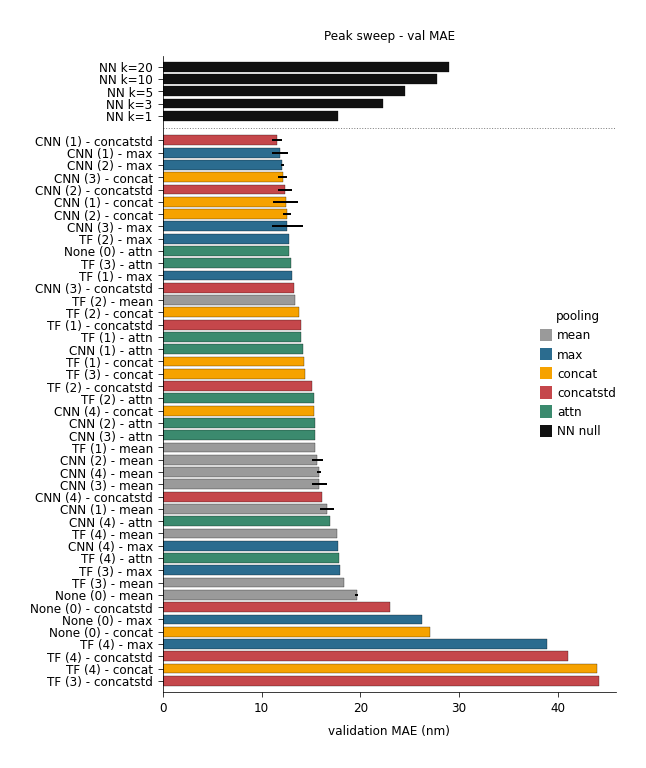

In [44]:
plot_bar(peak, "nm", "Peak sweep - val MAE", nulls=embed_nulls("peak"))

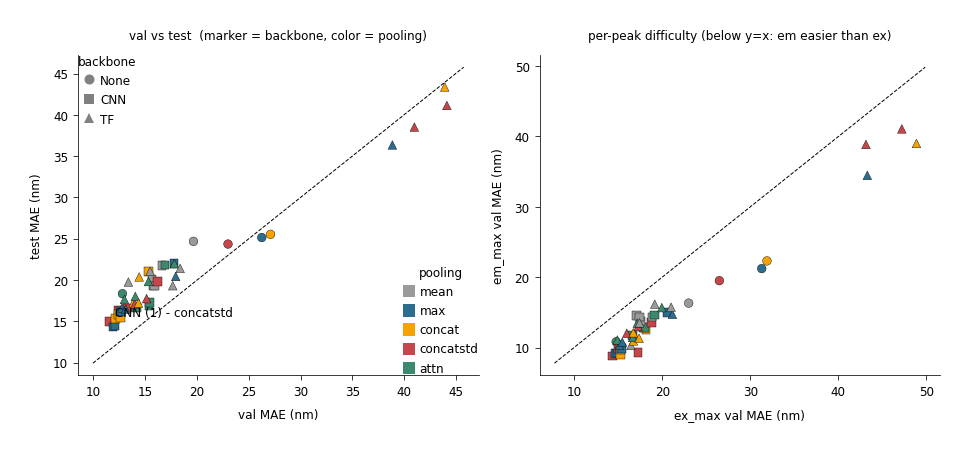

In [29]:
plot_scatter(peak, "nm", per_peak=True)

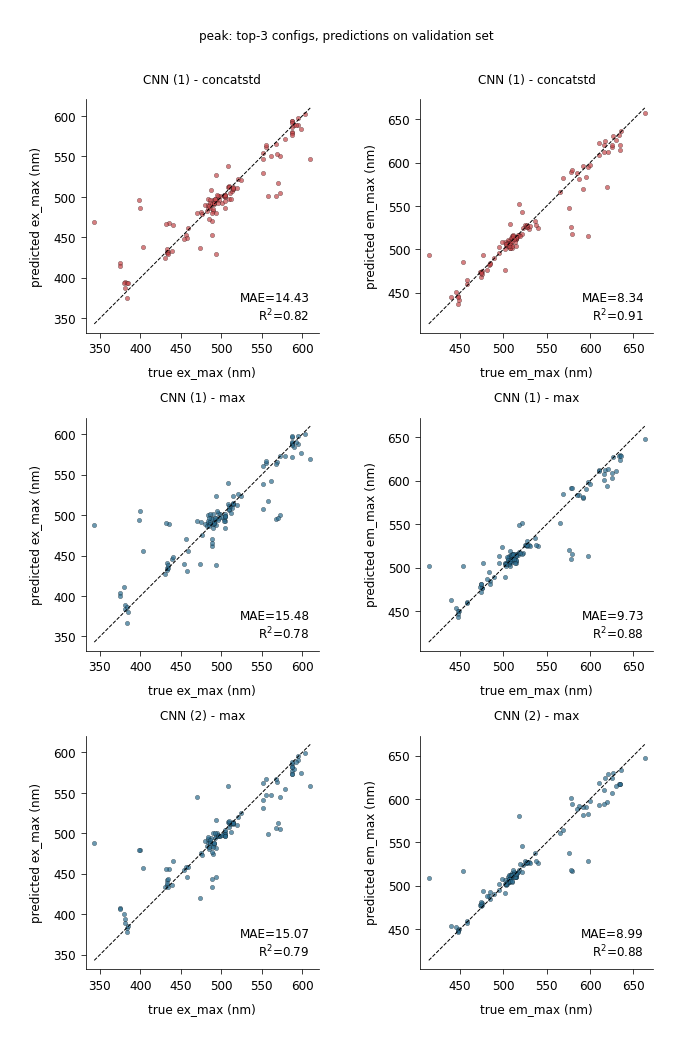

In [30]:
pred_vs_truth("peak", peak, "trained_models/oracle_sweep")

## Brightness - 70/15/15 split (log-brightness units)

In [31]:
bri = load_sweep("trained_models_brightness/sweep")
show_table(bri)

,label,arch,pool,depth,n_seeds,val_mae,val_std,test_mae,test_std
0,TF (1) - max,transformer,max,1,1,0.526,0.0,0.654,0.0
1,CNN (1) - concat,cnn,concat,1,1,0.541,0.0,0.640,0.0
2,TF (1) - concat,transformer,concat,1,1,0.563,0.0,0.640,0.0
3,CNN (1) - max,cnn,max,1,1,0.563,0.0,0.610,0.0
4,CNN (1) - concatstd,cnn,concatstd,1,1,0.564,0.0,0.626,0.0
5,TF (2) - concat,transformer,concat,2,1,0.572,0.0,0.610,0.0
6,TF (1) - concatstd,transformer,concatstd,1,1,0.583,0.0,0.619,0.0
7,CNN (3) - concatstd,cnn,concatstd,3,1,0.585,0.0,0.690,0.0
8,CNN (2) - concatstd,cnn,concatstd,2,1,0.594,0.0,0.627,0.0
9,CNN (2) - max,cnn,max,2,1,0.596,0.0,0.622,0.0


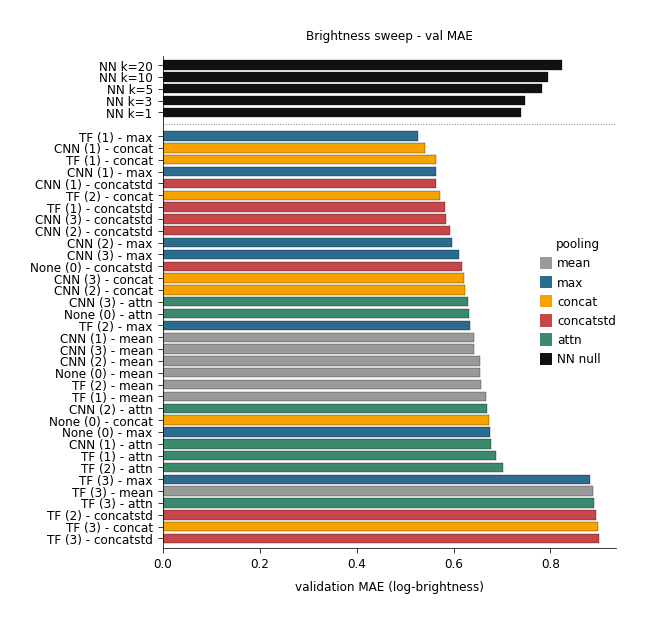

In [45]:
plot_bar(bri, "log-brightness", "Brightness sweep - val MAE", nulls=embed_nulls("brightness"))

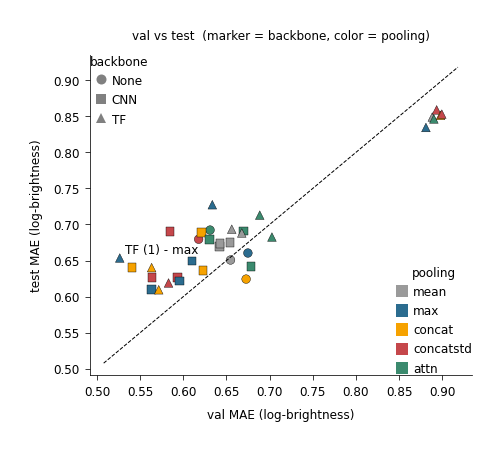

In [33]:
plot_scatter(bri, "log-brightness", per_peak=False)

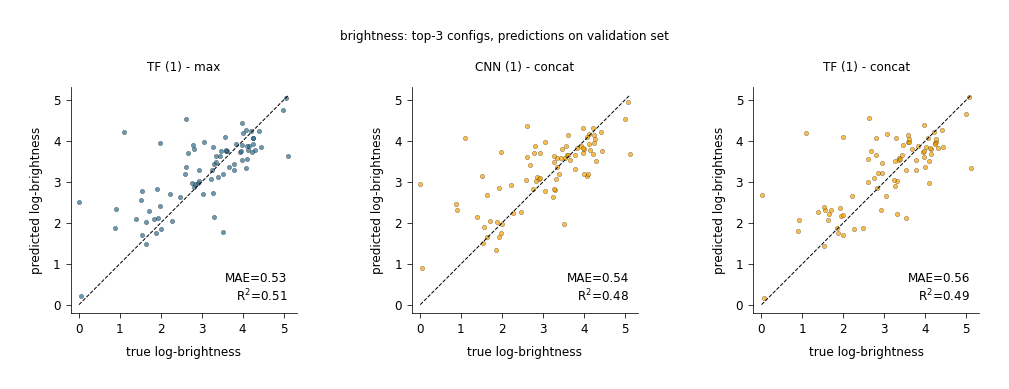

In [34]:
pred_vs_truth("brightness", bri, "trained_models_brightness/sweep")

## pKa - 70/15/15 split (pH units)

In [35]:
pka = load_sweep("trained_models_pka/sweep")
show_table(pka)

,label,arch,pool,depth,n_seeds,val_mae,val_std,test_mae,test_std
0,CNN (1) - attn,cnn,attn,1,1,0.546,0.0,0.840,0.0
1,CNN (2) - mean,cnn,mean,2,1,0.573,0.0,0.785,0.0
2,CNN (2) - attn,cnn,attn,2,1,0.597,0.0,0.788,0.0
3,CNN (2) - concat,cnn,concat,2,1,0.599,0.0,0.797,0.0
4,CNN (1) - concatstd,cnn,concatstd,1,1,0.601,0.0,0.758,0.0
5,CNN (1) - concat,cnn,concat,1,1,0.605,0.0,0.689,0.0
6,CNN (1) - mean,cnn,mean,1,1,0.607,0.0,0.824,0.0
7,None (0) - attn,mlp,attn,0,1,0.610,0.0,0.806,0.0
8,CNN (1) - max,cnn,max,1,1,0.612,0.0,0.730,0.0
9,None (0) - mean,mlp,mean,0,1,0.613,0.0,0.825,0.0


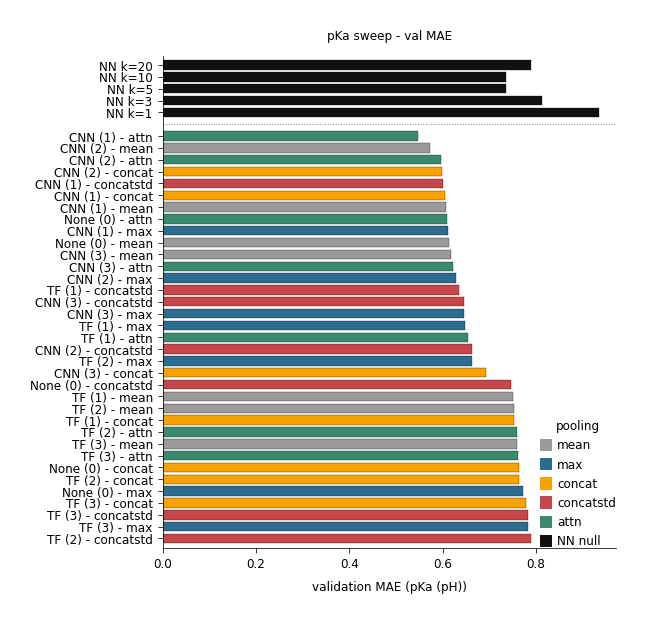

In [46]:
plot_bar(pka, "pKa (pH)", "pKa sweep - val MAE", nulls=embed_nulls("pka"))

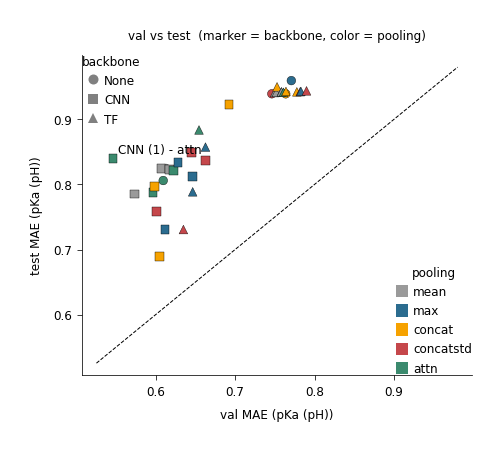

In [47]:
plot_scatter(pka, "pKa (pH)", per_peak=False)

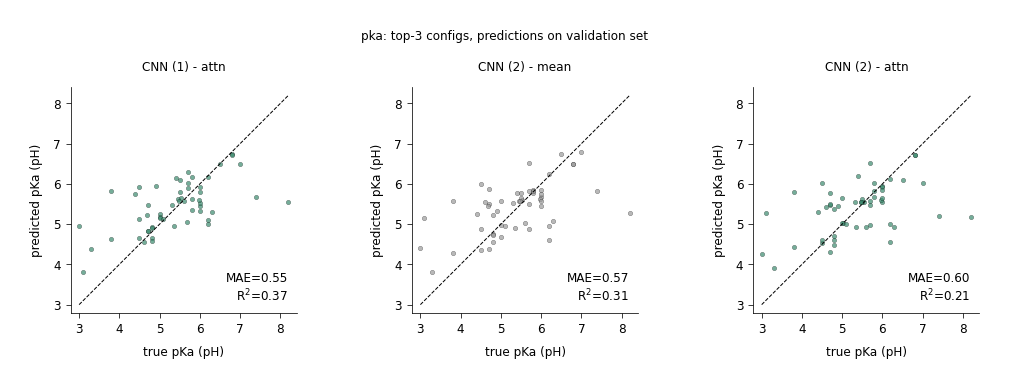

In [38]:
pred_vs_truth("pka", pka, "trained_models_pka/sweep")